In [119]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
from pathlib import Path

## Loading of Data

### CASH Output

In [ ]:
DATA_DIR = Path("C:/Users/P70099789/OneDrive - Maastricht University/Documents/GitHub/games-and-genes/data/")
RESULT_DIR = Path("C:/Users/P70099789/OneDrive - Maastricht University/Documents/GitHub/games-and-genes/results/")
DATASET = "E-MTAB-6698_rand"
RUN = "latest"
COMPARISON = "normal_vs_tumor"
DIRECTION = "plus"

if DIRECTION == "minus":
    df_results = pd.read_csv(RESULT_DIR / DATASET / RUN / COMPARISON / "results_minus.csv", index_col=0)
else:
    df_results = pd.read_csv(RESULT_DIR / DATASET / RUN / COMPARISON / "results_plus.csv", index_col=0)

df_results.head()

,shapley_case,shapley_control,observed_difference,observed_abs_difference,bootstrap_se,zscore,abs_zscore,pval,pval_adj
RFC2,0.000059,0.000043,0.000016,0.000016,0.000011,1.440677,1.440677,0.144,0.992570
HSPA6,0.000052,0.000044,0.000007,0.000007,0.000014,0.528885,0.528885,0.611,0.996172
PAX8,0.000036,0.000037,-0.000001,0.000001,0.000011,-0.108971,0.108971,0.910,0.998643
GUCA1A,0.000039,0.000049,-0.000010,0.000010,0.000013,-0.776306,0.776306,0.443,0.996172
THRA,0.000034,0.000053,-0.000019,0.000019,0.000013,-1.495672,1.495672,0.130,0.992570


In [121]:
def filter_and_sort_df(df: pd.DataFrame, pval_threshold=0.05):
    df = df[df["pval"] < pval_threshold]
    df = df[df["shapley_case"] > df["shapley_case"].mean() + df["shapley_case"].std()]

    # return df.sort_values(["pval_adj", "abs_zscore"], ascending=[True, False])
    return df.sort_values("shapley_case", ascending=False)

df_results_filtered = filter_and_sort_df(df_results)

df_results_filtered.head()

,shapley_case,shapley_control,observed_difference,observed_abs_difference,bootstrap_se,zscore,abs_zscore,pval,pval_adj
LYZ,0.000116,0.000065,0.000051,0.000051,0.000017,2.957981,2.957981,0.005,0.808858
OSGEP,0.000105,0.000063,0.000042,0.000042,0.000017,2.422846,2.422846,0.018,0.975489
LOC100288570,0.000104,0.000040,0.000064,0.000064,0.000013,4.760295,4.760295,0.000,0.000000
ARSJ,0.000104,0.000051,0.000053,0.000053,0.000015,3.468974,3.468974,0.000,0.000000
TUBB2A,0.000103,0.000043,0.000060,0.000060,0.000015,4.097399,4.097399,0.000,0.000000


### Original Expression Data

In [122]:
df_expression = pd.read_csv(DATA_DIR / DATASET / "processed/expression.csv", index_col=0)
df_samples = pd.read_csv(DATA_DIR / DATASET / "processed/samples.csv", index_col=0)

df_samples = df_samples.reindex(df_expression.columns)
df_samples.head()

,Characteristics[organism],Characteristics[disease],Characteristics[GEO accession number],Characteristics[sex],Characteristics[age],Unit[time unit],Characteristics[stage],Characteristics[grade],Characteristics[tumor content],Characteristics[overall survival (months)],...,Assay Name,Technology Type,Array Design REF,Term Source REF,Protocol REF.4,Protocol REF.5,Derived Array Data File,Comment [Derived ArrayExpress FTP file],Factor Value[disease],Factor Value[macro/microdissection]
GSM93938.CEL,Homo sapiens,tumor,GSE4107,female,45.0,year,0.0,NaN,NaN,NaN,...,GSM93938.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,normal,Macrodissected
GSM93939.CEL,Homo sapiens,normal,GSE4107,female,44.0,year,0.0,NaN,NaN,NaN,...,GSM93939.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,normal,Macrodissected
GSM93941.CEL,Homo sapiens,tumor,GSE4107,female,41.0,year,0.0,NaN,NaN,NaN,...,GSM93941.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,normal,Macrodissected
GSM93943.CEL,Homo sapiens,tumor,GSE4107,male,28.0,year,0.0,NaN,NaN,NaN,...,GSM93943.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,normal,Macrodissected
GSM93944.CEL,Homo sapiens,tumor,GSE4107,male,27.0,year,0.0,NaN,NaN,NaN,...,GSM93944.CEL:biotin,array assay,A-AFFY-44,ArrayExpress,P-MTAB-74103,P-MTAB-74104,esets_colorectal_exprs_genes.txt,ftp://ftp.ebi.ac.uk/pub/databases/microarray/d...,normal,Macrodissected


In [123]:
df_expression.shape

(20545, 443)

## Analysis of CASh Output

### Unsupervised Sample Classification

In [124]:
true_labels = pd.Series(df_samples["Characteristics[disease]"].map({"normal": 0, "tumor": 1}), index=df_samples.index)

NUM_TOP_GENES = 100

df_results_filtered_top = df_results_filtered.head(min(len(df_results), NUM_TOP_GENES))
top_genes_plus = df_results_filtered_top.index.tolist()

In [125]:
def clustering_analysis(df: pd.DataFrame, genes: list, true_labels: pd.Series):
    df = df.loc[genes]
    X = df.T  
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
    kmeans_labels = pd.Series(kmeans.fit_predict(X_scaled), index=X.index)

    true_lut = dict(zip(true_labels.unique(), sns.color_palette("Set1", len(true_labels.unique()))))
    true_colors = true_labels.map(true_lut)
    kmeans_lut = dict(zip(kmeans_labels.unique(), sns.color_palette("Set2", len(kmeans_labels.unique()))))
    kmeans_colors = kmeans_labels.map(kmeans_lut)
    annotation_colors = pd.DataFrame({
        'True Labels': true_colors,
        'KMeans': kmeans_colors
    })

    g = sns.clustermap(
        X_scaled_df.T, 
        col_colors=annotation_colors,
        figsize=(16, 14),
        cmap="coolwarm",
        z_score=None,          # Already scaled
        yticklabels=True,      # Show gene names
        xticklabels=False      # Hide sample names to avoid clutter
    )
    
    for label, color in true_lut.items():
        g.ax_col_dendrogram.bar(0, 0, color=color, label=f"True: {label}", linewidth=0)
    for label, color in kmeans_lut.items():
        g.ax_col_dendrogram.bar(0, 0, color=color, label=f"KMeans: {label}", linewidth=0)

    g.ax_col_dendrogram.legend(loc="center", ncol=2, bbox_to_anchor=(0.5, 1.2), frameon=False)
    
    plt.show()

    return kmeans_labels

c:\Users\P70099789\AppData\Local\miniconda3\envs\games-and-genes\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\P70099789\AppData\Local\miniconda3\envs\games-and-genes\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\P70099789\AppData\Local\miniconda3\envs\games-and-genes\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


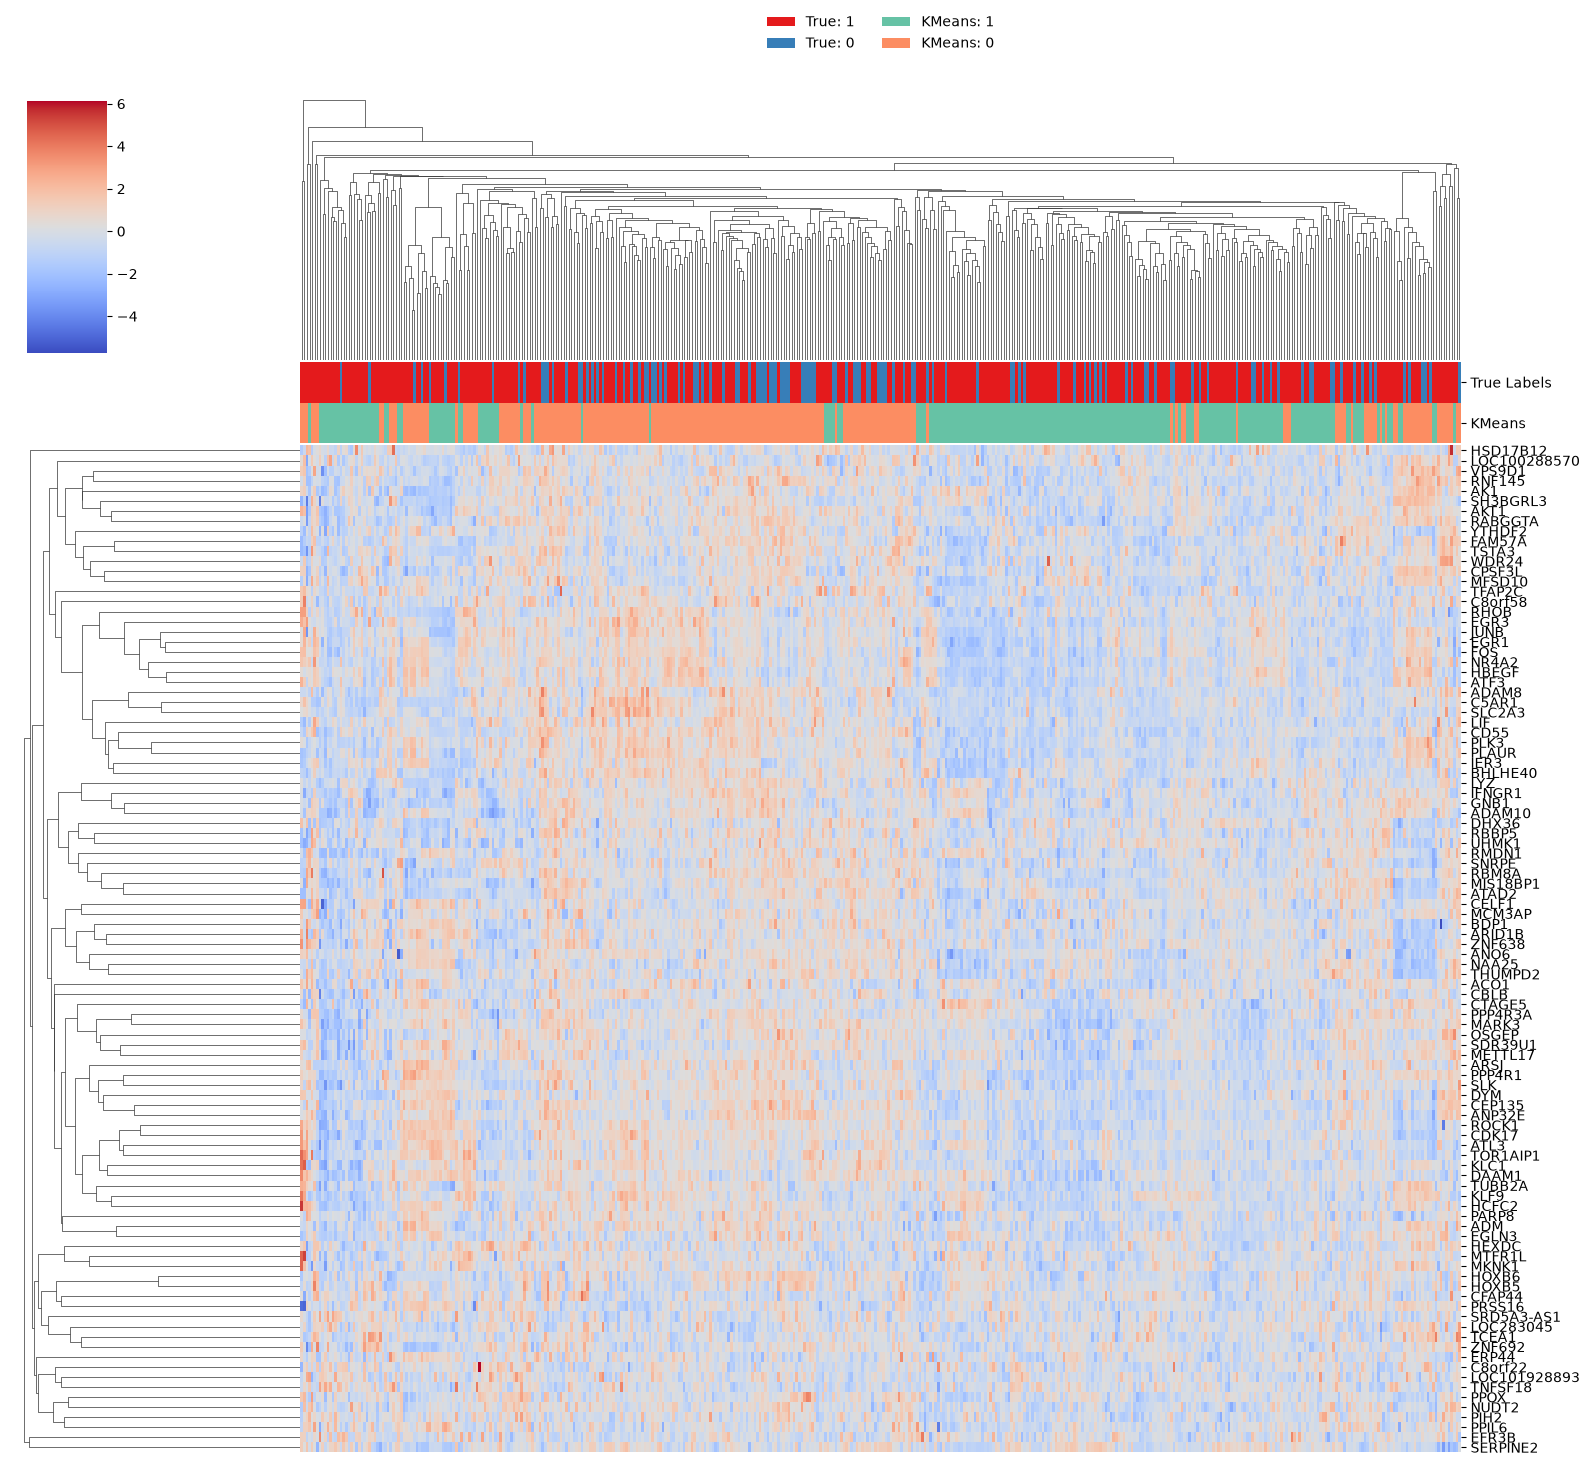

In [126]:
kmeans_labels = clustering_analysis(df_expression, top_genes_plus, true_labels)

In [127]:
df_combined = true_labels.to_frame(name="true").join(kmeans_labels.to_frame(name="kmeans"))
df_combined.corr(method='pearson')

,true,kmeans
true,1.0000,0.1787
kmeans,0.1787,1.0000


### PCA

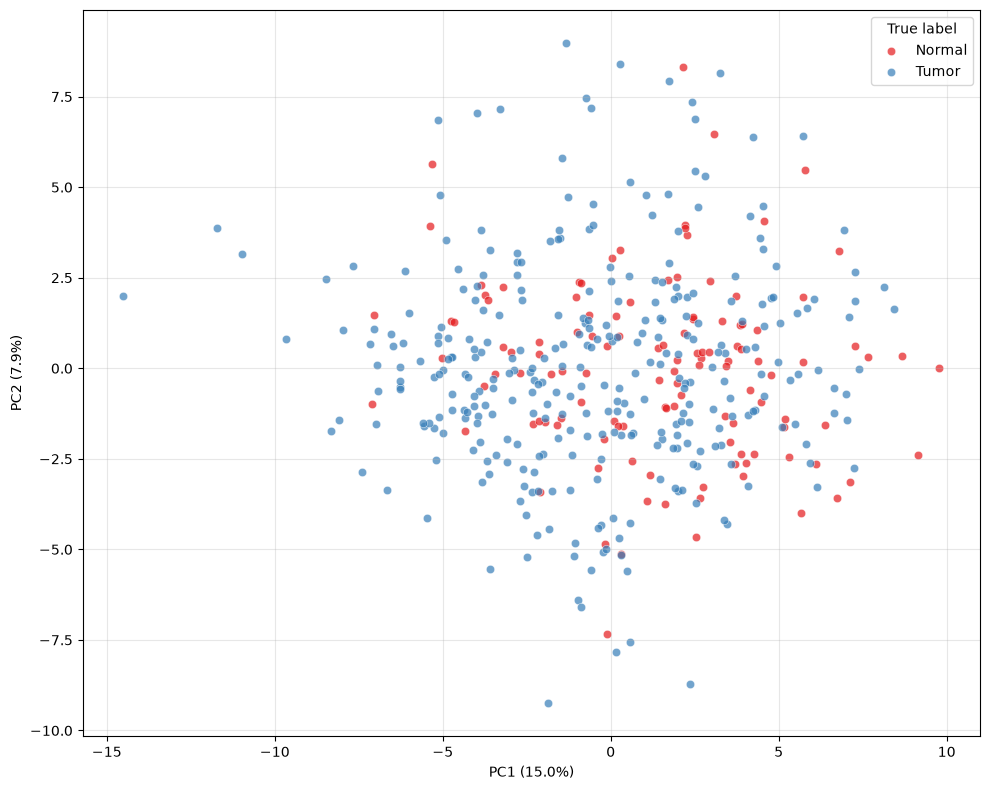

In [128]:
X_top = df_expression.loc[top_genes_plus].T

X_top_scaled = StandardScaler().fit_transform(X_top)

pca_top = PCA(n_components=2)
X_pca_top = pca_top.fit_transform(X_top_scaled)

plt.figure(figsize=(10, 8))

for label, color in zip([0, 1], sns.color_palette("Set1", 2)):
    mask = true_labels.to_numpy() == label
    plt.scatter(
        X_pca_top[mask, 0],
        X_pca_top[mask, 1],
        label={0: "Normal", 1: "Tumor"}[label],
        color=color,
        alpha=0.7,
        edgecolor="white",
        linewidth=0.4,
    )

plt.xlabel(f"PC1 ({pca_top.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca_top.explained_variance_ratio_[1] * 100:.1f}%)")
plt.legend(title="True label")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()